# ReachGrasp: native timing, phase, and endpoint structure

We test whether differences between movement endpoints account for much of the difference between whole trajectories. Each observation is a complete recorded movement, indexed by dataset, subject, action, and repetition. This is a representation diagnostic, not primitive discovery.

**What:** retain native joint trajectories and compare phase-normalized trajectories with their endpoint residuals. **How:** use the canonical collection produced by `scripts/prepare_reachgrasp.py`, without SOC gains, readouts, smoothing, or amplitude scaling. **Software:** ReachGrasp's existing loader, NumPy, SciPy, pandas, and Matplotlib. **Output:** numerical distances, descriptive correlations, provenance, and figures in a named results directory.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
from motion_primitives.paths import PROJECT_ROOT
from motion_primitives.preprocessing import load_collections

COLLECTIONS = [PROJECT_ROOT / 'collections/ReachGrasp/vicon-phase200-v1']
JOINT_NAMES = None  # None uses all 31 recorded channels; an explicit list selects/reorders channels.
OUTPUT = PROJECT_ROOT / 'notebooks/results/01_ReachGrasp_Preprocessing' / COLLECTIONS[0].name
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'savefig.dpi': 200, 'figure.constrained_layout.use': True})
collection = load_collections(COLLECTIONS, JOINT_NAMES)
Q, H, F = (collection[key] for key in ('q', 'h', 'f'))
metadata, joints = collection['metadata'], collection['joint_names']
phase = np.linspace(0, 1, Q.shape[1])
units = collection['manifests'][0]['units']
print(f'{len(metadata)} movements; {len(joints)} joints; {Q.shape[1]} phase samples; units: {units}')
display(metadata.groupby('dataset').agg(movements=('movement_id', 'size'),
    subjects=('subject', 'nunique'), actions=('action', 'nunique'),
    min_duration_s=('duration_seconds', 'min'), max_duration_s=('duration_seconds', 'max')))
print('Explicit exclusions:', collection['manifests'][0]['excluded_recordings'])

1434 movements; 31 joints; 200 phase samples; units: degrees


,movements,subjects,actions,min_duration_s,max_duration_s
dataset,,,,,
ReachGrasp,1434,10,16,1.199999,8.600001


Explicit exclusions: ['sub-09/HC']


## Native timing and separate phase representation

For native samples $q_a(t_i)$, define $\phi_i=(t_i-t_0)/(t_f-t_0)$ and linearly interpolate onto a common grid $\phi\in[0,1]$. Linear interpolation preserves measured endpoints and introduces no smoothing. A normalized phase is not physical time: speed and duration remain available only in the native data.

**Reference:** ordinary linear interpolation; no movement-primitive model is needed. **Software:** `numpy.interp`. **Output:** `native.npz` stores concatenated native arrays with movement offsets; `phase.npz` stores $Q\in\mathbb{R}^{A\times T\times D}$. The native archive retains every selected sample and its elapsed time.

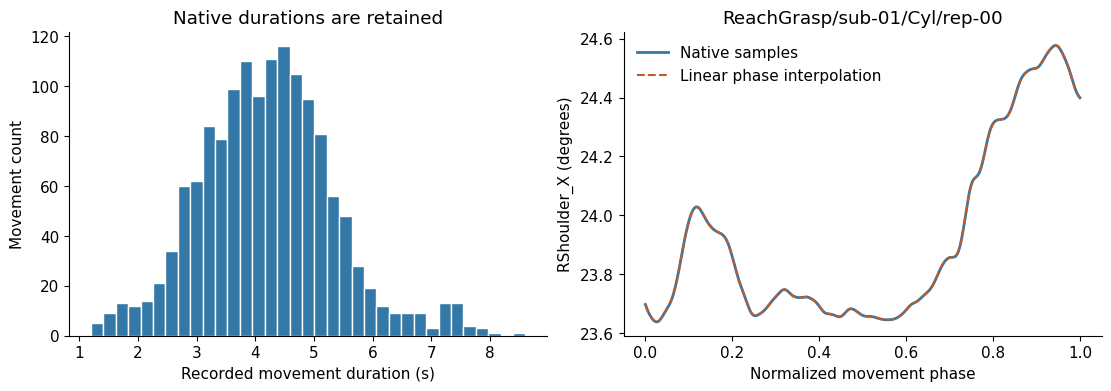

In [2]:
with np.load(COLLECTIONS[0] / 'native.npz') as native:
    offsets = native['offsets']
    a = 0
    start, stop = offsets[a:a + 2]
    native_time = native['time'][start:stop]
    native_q = native['q'][start:stop]
    native_names = native['joint_names'].tolist()
    np.testing.assert_array_equal(native_q[0, [native_names.index(name) for name in joints]], Q[a, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(metadata.duration_seconds, bins=35, color='#3478a7', edgecolor='white')
axes[0].set(xlabel='Recorded movement duration (s)', ylabel='Movement count', title='Native durations are retained')
j = joints.index('RShoulder_X')
axes[1].plot(native_time / native_time[-1], native_q[:, native_names.index(joints[j])],
             label='Native samples', color='#3478a7', linewidth=2)
axes[1].plot(phase, Q[a, :, j], '--', label='Linear phase interpolation', color='#c05a28')
axes[1].set(xlabel='Normalized movement phase', ylabel=f'{joints[j]} ({units})',
            title=metadata.iloc[a].movement_id)
axes[1].legend(frameon=False)
fig.savefig(OUTPUT / 'native_and_phase.png')
plt.show()

## Separate endpoint context from observed shape

For every movement, compute
$$h_a(\phi)=q_{0,a}+\phi(q_{g,a}-q_{0,a}),\qquad f_a(\phi)=q_a(\phi)-h_a(\phi).$$
Here $q_{0,a}$ and $q_{g,a}$ are the first and last measured joint configurations. The residual $f_a$ measures departure from the straight start-to-goal connection. Its endpoint values are zero by construction; that is not evidence for a primitive.

**Reference:** the elementary-trajectory plus shape decomposition in [Zhou, Gao & Asfour (2019), Learning Via-Point Movement Primitives](https://h2t.iar.kit.edu/pdf/Zhou2019.pdf), as specified in the project plan. This notebook computes the observed residual directly; it does not fit the VMP basis-function model. **Software:** NumPy broadcasting. **Output:** $H$, $F$, `q_start`, and `q_goal`, with exact reconstruction $Q=H+F$ up to floating-point precision.

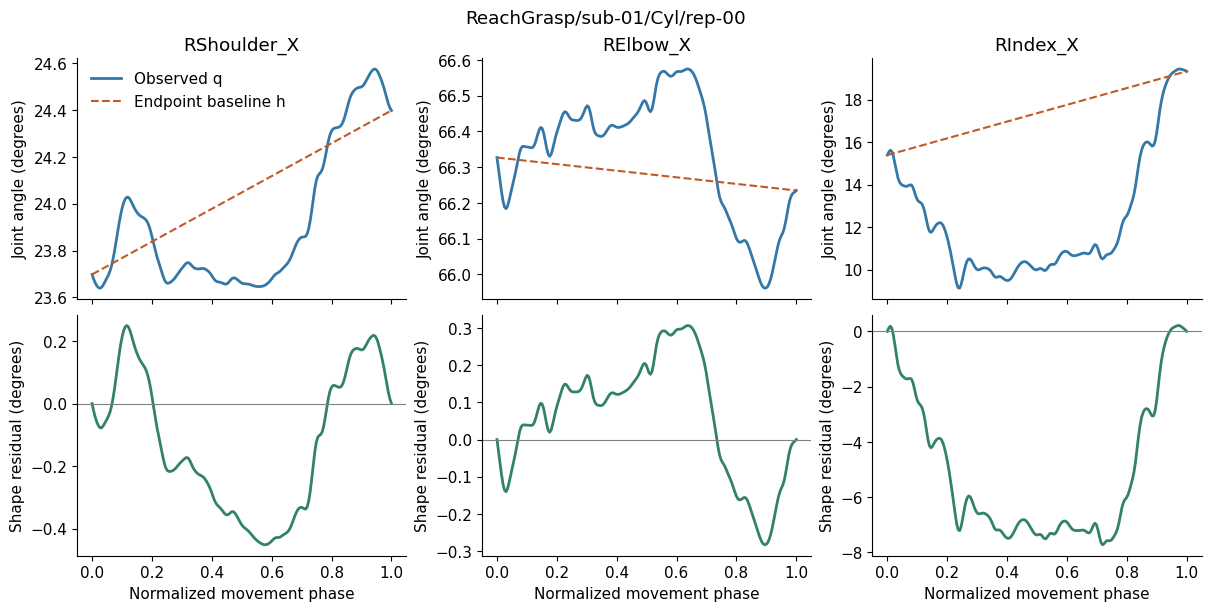

In [3]:
np.testing.assert_allclose(Q, H + F, atol=1e-12)
np.testing.assert_allclose(F[:, [0, -1]], 0, atol=1e-12)
example_joints = ['RShoulder_X', 'RElbow_X', 'RIndex_X']
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for column, name in enumerate(example_joints):
    j = joints.index(name)
    axes[0, column].plot(phase, Q[a, :, j], label='Observed q', color='#3478a7', linewidth=2)
    axes[0, column].plot(phase, H[a, :, j], '--', label='Endpoint baseline h', color='#c05a28')
    axes[0, column].set(title=name, ylabel=f'Joint angle ({units})')
    axes[1, column].plot(phase, F[a, :, j], color='#328267', linewidth=2)
    axes[1, column].axhline(0, color='0.5', linewidth=0.8)
    axes[1, column].set(xlabel='Normalized movement phase', ylabel=f'Shape residual ({units})')
axes[0, 0].legend(frameon=False)
fig.suptitle(metadata.iloc[a].movement_id)
fig.savefig(OUTPUT / 'endpoint_decomposition.png')
plt.show()

## Endpoint distances versus trajectory distances

For each unordered pair of movements $a,b$, compute
$$d_E=\|q_{0,a}-q_{0,b}\|_2+\|q_{g,a}-q_{g,b}\|_2,$$
$$d_Q=\sqrt{T^{-1}\sum_t\|q_a(t)-q_b(t)\|_2^2},\qquad
  d_F=\sqrt{T^{-1}\sum_t\|f_a(t)-f_b(t)\|_2^2}.$$
The division is by $T$, not $TD$: distances are the root mean squared joint-vector norm. All channels have equal weight in their recorded degree units.

**Reference:** this is the project's proposed endpoint diagnostic, not a published primitive-discovery test. **Software:** SciPy `pdist`, `pearsonr`, and `spearmanr`. **Output:** all pair distances and descriptive correlations. A substantially smaller association with $d_F$ than $d_Q$ supports endpoint separation as a useful representation. It does not demonstrate reusable motor primitives. Pair distances share movements, so they are not independent observations; no ordinary correlation p-values are interpreted.

In [4]:
distances = {'endpoint': pdist(Q[:, 0]) + pdist(Q[:, -1])}
for name, values in tqdm([('trajectory', Q), ('shape', F)], desc='Pairwise trajectory distances'):
    distances[name] = pdist(values.reshape(len(values), -1)) / np.sqrt(Q.shape[1])
summary = pd.DataFrame([dict(representation=name,
    pearson_r=pearsonr(distances['endpoint'], distances[name]).statistic,
    spearman_r=spearmanr(distances['endpoint'], distances[name]).statistic)
    for name in ('trajectory', 'shape')])
display(summary)
summary.to_csv(OUTPUT / 'correlations.csv', index=False)
np.savez_compressed(OUTPUT / 'pair_distances.npz', **distances,
                    movement_ids=metadata.movement_id.to_numpy(dtype=str))
provenance = dict(collections=[dict(path=str(p), manifest_sha256=hashlib.sha256(
    (p / 'manifest.json').read_bytes()).hexdigest()) for p in COLLECTIONS], joint_names=joints,
    distance='Euclidean joint-vector RMS over phase; equal joint weights',
    pairs='scipy pdist condensed order', pair_count=len(distances['endpoint']))
(OUTPUT / 'provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')

Pairwise trajectory distances:   0%|          | 0/2 [00:00<?, ?it/s]

,representation,pearson_r,spearman_r
0,trajectory,0.967520,0.902412
1,shape,0.321029,0.444805


953

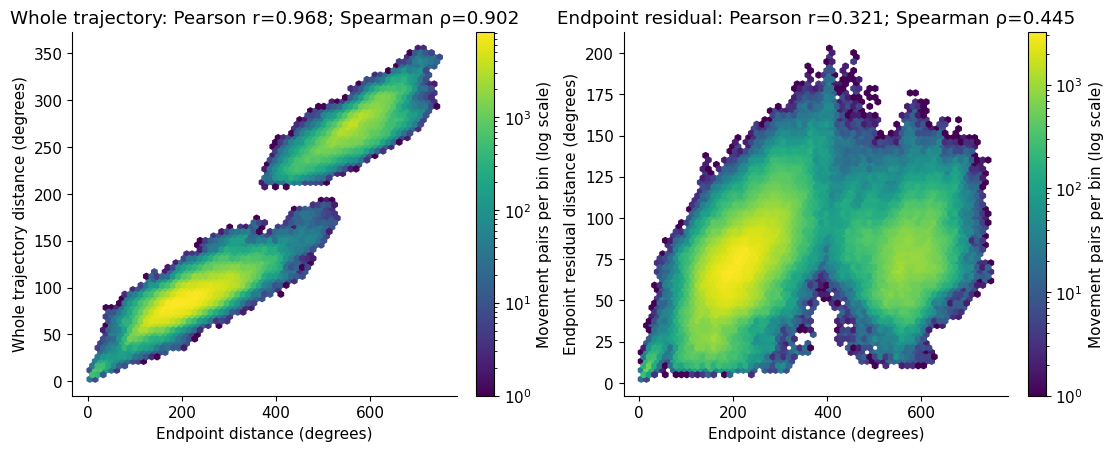

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, name, title in zip(axes, ['trajectory', 'shape'], ['Whole trajectory', 'Endpoint residual']):
    density = ax.hexbin(distances['endpoint'], distances[name], gridsize=65, bins='log',
                        mincnt=1, cmap='viridis', rasterized=True)
    row = summary.set_index('representation').loc[name]
    ax.set(xlabel=f'Endpoint distance ({units})', ylabel=f'{title} distance ({units})',
           title=f'{title}: Pearson r={row.pearson_r:.3f}; Spearman ρ={row.spearman_r:.3f}')
    fig.colorbar(density, ax=ax, label='Movement pairs per bin (log scale)')
fig.savefig(OUTPUT / 'endpoint_distance_association.png')
plt.show()

## Interpretation and next experiment

Compare both coefficients and the density plots. Endpoint separation can remove a large baseline component while retaining meaningful shape variability, but it can also remove scientifically relevant posture information. Therefore, primitive discovery must compare `q` and `f` using the same complete-movement train/validation/test split.

FADA, SCA, geodesic extraction, candidate selection, and SOC context conditioning are separate experiments. This notebook does not execute or validate those experiments. Native movement duration must remain attached to every primitive occurrence or contextual reconstruction.